## 1. Load data

import libaries and dataset

In [1]:
import pandas as pd
import mlflow
import itertools
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import time

df = pd.read_csv("data/Cars.csv")

## 2. EDA

### Explore

In [2]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 1.6 MB


In [4]:
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        print(f"{col}: {df[col].min()} - {df[col].max()}")
    else:
        print(f"{col} ({df[col].nunique()}): {df[col].unique().tolist()[:10]}")

name (2058): ['Maruti Swift Dzire VDI', 'Skoda Rapid 1.5 TDI Ambition', 'Honda City 2017-2020 EXi', 'Hyundai i20 Sportz Diesel', 'Maruti Swift VXI BSIII', 'Hyundai Xcent 1.2 VTVT E Plus', 'Maruti Wagon R LXI DUO BSIII', 'Maruti 800 DX BSII', 'Toyota Etios VXD', 'Ford Figo Diesel Celebration Edition']
year: 1983 - 2020
selling_price: 29999 - 10000000
km_driven: 1 - 2360457
fuel (4): ['Diesel', 'Petrol', 'LPG', 'CNG']
seller_type (3): ['Individual', 'Dealer', 'Trustmark Dealer']
transmission (2): ['Manual', 'Automatic']
owner (5): ['First Owner', 'Second Owner', 'Third Owner', 'Fourth & Above Owner', 'Test Drive Car']
mileage (393): ['23.4 kmpl', '21.14 kmpl', '17.7 kmpl', '23.0 kmpl', '16.1 kmpl', '20.14 kmpl', '17.3 km/kg', '23.59 kmpl', '20.0 kmpl', '19.01 kmpl']
engine (121): ['1248 CC', '1498 CC', '1497 CC', '1396 CC', '1298 CC', '1197 CC', '1061 CC', '796 CC', '1364 CC', '1399 CC']
max_power (322): ['74 bhp', '103.52 bhp', '78 bhp', '90 bhp', '88.2 bhp', '81.86 bhp', '57.5 bhp', '3

### map data based on the assignment

#### owner

In [5]:
owner_map = {
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4,
    "Test Drive Car": 5,
}
df["owner"] = df["owner"].map(owner_map)
df["owner"].head()

0    1
1    2
2    3
3    1
4    1
Name: owner, dtype: int64

#### fuel

In [6]:
df = df[~df["fuel"].isin(["LPG", "CNG"])]
df["fuel"].unique()

<ArrowStringArray>
['Diesel', 'Petrol']
Length: 2, dtype: str

#### mileage

In [7]:
df["mileage"] = df["mileage"].str.split(" ").str[0]
df["mileage"] = pd.to_numeric(df["mileage"], errors="coerce")
df["mileage"].head()

0    23.40
1    21.14
2    17.70
3    23.00
4    16.10
Name: mileage, dtype: float64

#### engine

In [8]:
df["engine"] = df["engine"].str.split(" ").str[0]
df["engine"] = pd.to_numeric(df["engine"], errors="coerce")
df["engine"].head()

0    1248.0
1    1498.0
2    1497.0
3    1396.0
4    1298.0
Name: engine, dtype: float64

#### max power

In [9]:
df["max_power"] = df["max_power"].str.split(" ").str[0]
df["max_power"] = pd.to_numeric(df["max_power"], errors="coerce")
df["max_power"].head()

0     74.00
1    103.52
2     78.00
3     90.00
4     88.20
Name: max_power, dtype: float64

#### name

In [10]:
df["name"] = df["name"].str.split(" ").str[0].astype(str)

df["name"].head()

0     Maruti
1      Skoda
2      Honda
3    Hyundai
4     Maruti
Name: name, dtype: str

#### torque

In [11]:
df = df.drop(columns=["torque"])
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats'],
      dtype='str')

#### drop Test Drive Cars

In [12]:
df = df[df["owner"] != 5]
df["owner"].unique()

array([1, 2, 3, 4])

### Explore again after EDA

In [13]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0


In [14]:
df.info()

<class 'pandas.DataFrame'>
Index: 8028 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8028 non-null   str    
 1   year           8028 non-null   int64  
 2   selling_price  8028 non-null   int64  
 3   km_driven      8028 non-null   int64  
 4   fuel           8028 non-null   str    
 5   seller_type    8028 non-null   str    
 6   transmission   8028 non-null   str    
 7   owner          8028 non-null   int64  
 8   mileage        7814 non-null   float64
 9   engine         7814 non-null   float64
 10  max_power      7820 non-null   float64
 11  seats          7814 non-null   float64
dtypes: float64(4), int64(4), str(4)
memory usage: 1.0 MB


In [15]:
for col in df.columns:
    if df[col].dtype == "str":
        print(f"{col} ({df[col].nunique()}): {df[col].unique().tolist()[:10]}")
    else:
        min = df[col].min()
        max = df[col].max()
        print(f"{col}: {min} - {max}")

name (32): ['Maruti', 'Skoda', 'Honda', 'Hyundai', 'Toyota', 'Ford', 'Renault', 'Mahindra', 'Tata', 'Chevrolet']
year: 1983 - 2020
selling_price: 29999 - 10000000
km_driven: 1000 - 2360457
fuel (2): ['Diesel', 'Petrol']
seller_type (3): ['Individual', 'Dealer', 'Trustmark Dealer']
transmission (2): ['Manual', 'Automatic']
owner: 1 - 4
mileage: 0.0 - 42.0
engine: 624.0 - 3604.0
max_power: 0.0 - 400.0
seats: 2.0 - 14.0


## 3. Feature selection

we encode all possible features to see if there any hidden correlation between them and target

### Encoding categorical data

#### Label encoding

In [16]:
label_encoding_df = df.copy()

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

label_encoding_df["name"] = le.fit_transform(df["name"])
mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(mapping)

{'Ambassador': 0, 'Ashok': 1, 'Audi': 2, 'BMW': 3, 'Chevrolet': 4, 'Daewoo': 5, 'Datsun': 6, 'Fiat': 7, 'Force': 8, 'Ford': 9, 'Honda': 10, 'Hyundai': 11, 'Isuzu': 12, 'Jaguar': 13, 'Jeep': 14, 'Kia': 15, 'Land': 16, 'Lexus': 17, 'MG': 18, 'Mahindra': 19, 'Maruti': 20, 'Mercedes-Benz': 21, 'Mitsubishi': 22, 'Nissan': 23, 'Opel': 24, 'Peugeot': 25, 'Renault': 26, 'Skoda': 27, 'Tata': 28, 'Toyota': 29, 'Volkswagen': 30, 'Volvo': 31}


In [18]:
label_encoding_df["fuel"] = le.fit_transform(df["fuel"])
mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(mapping)

{'Diesel': 0, 'Petrol': 1}


In [19]:
label_encoding_df["seller_type"] = le.fit_transform(df["seller_type"])
mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(mapping)

{'Dealer': 0, 'Individual': 1, 'Trustmark Dealer': 2}


In [20]:
label_encoding_df["transmission"] = le.fit_transform(df["transmission"])
mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(mapping)

{'Automatic': 0, 'Manual': 1}


<Axes: >

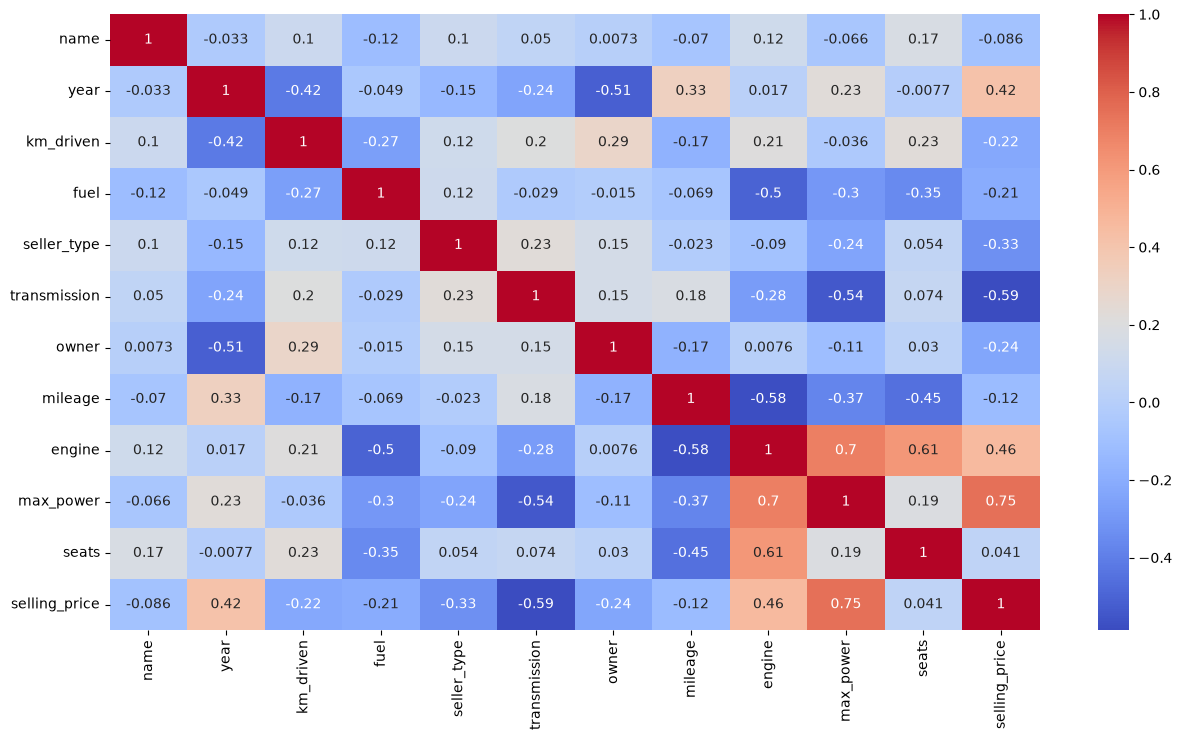

In [21]:
label_encoding_df['selling_price'] = label_encoding_df.pop('selling_price')

plt.figure(figsize=(15, 8))
sns.heatmap(label_encoding_df.corr(), annot=True, cmap="coolwarm")

#### One-hot encoding

In [22]:
one_hot_encoding_df = df.copy()

In [23]:
one_hot_encoding_df = pd.get_dummies(df, columns=["name", "fuel", "seller_type", "transmission"], dtype=int)

one_hot_encoding_df['selling_price'] = one_hot_encoding_df.pop('selling_price')
one_hot_encoding_df.columns

Index(['year', 'km_driven', 'owner', 'mileage', 'engine', 'max_power', 'seats',
       'name_Ambassador', 'name_Ashok', 'name_Audi', 'name_BMW',
       'name_Chevrolet', 'name_Daewoo', 'name_Datsun', 'name_Fiat',
       'name_Force', 'name_Ford', 'name_Honda', 'name_Hyundai', 'name_Isuzu',
       'name_Jaguar', 'name_Jeep', 'name_Kia', 'name_Land', 'name_Lexus',
       'name_MG', 'name_Mahindra', 'name_Maruti', 'name_Mercedes-Benz',
       'name_Mitsubishi', 'name_Nissan', 'name_Opel', 'name_Peugeot',
       'name_Renault', 'name_Skoda', 'name_Tata', 'name_Toyota',
       'name_Volkswagen', 'name_Volvo', 'fuel_Diesel', 'fuel_Petrol',
       'seller_type_Dealer', 'seller_type_Individual',
       'seller_type_Trustmark Dealer', 'transmission_Automatic',
       'transmission_Manual', 'selling_price'],
      dtype='str')

<Axes: >

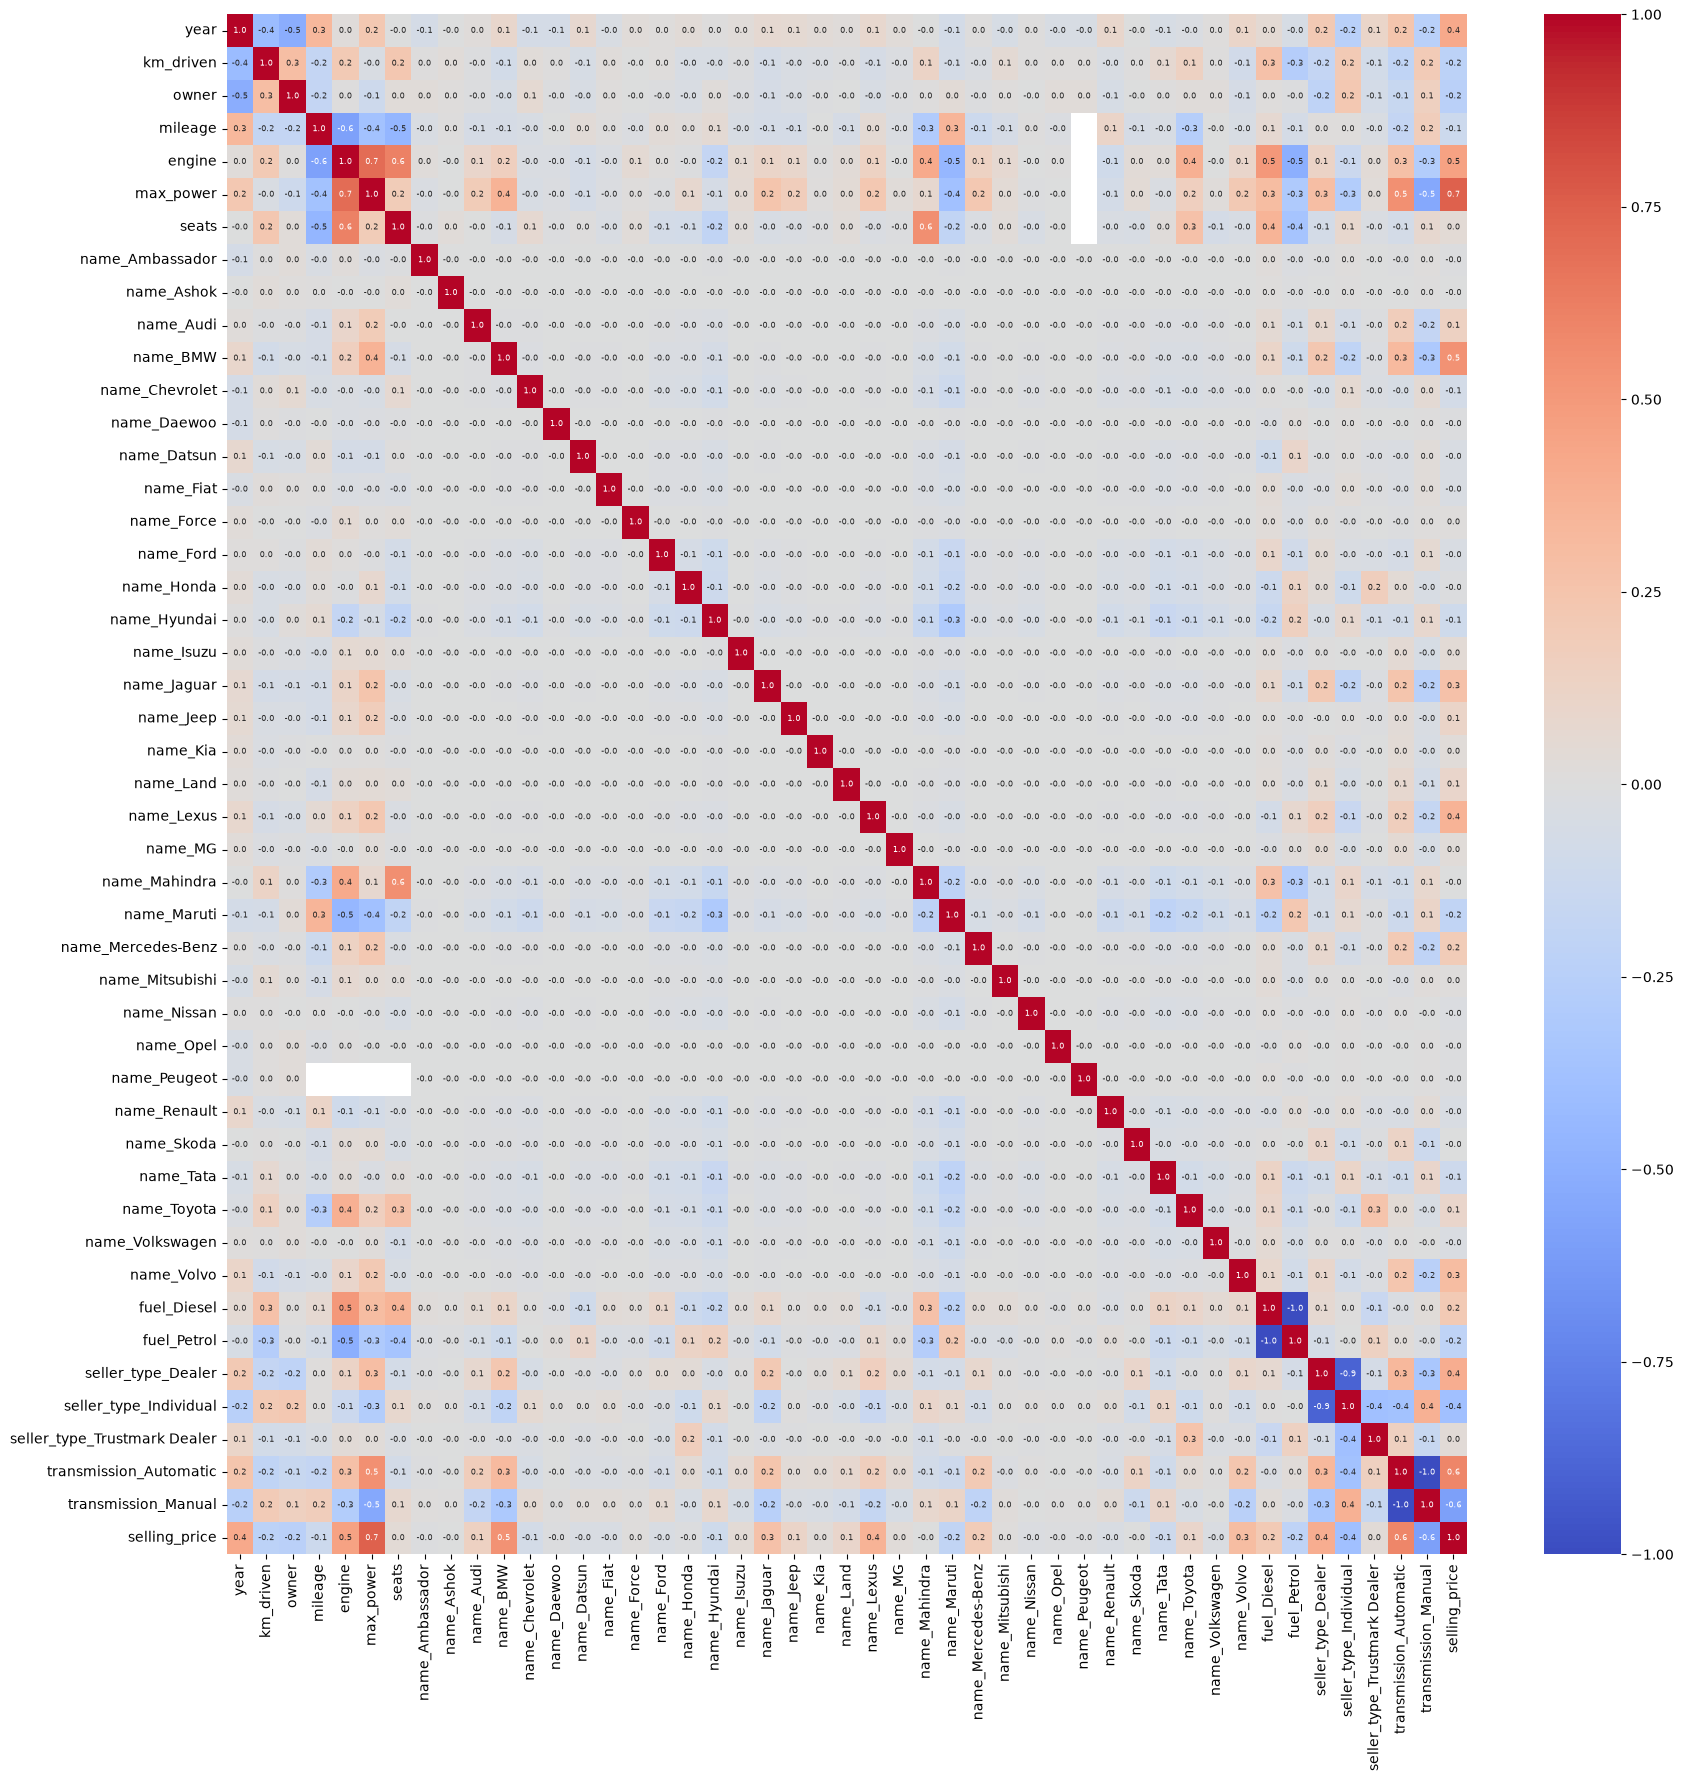

In [24]:
plt.figure(figsize=(20, 20))
# sns.heatmap(one_hot_encoding_df.corr(), annot=True, cmap="coolwarm")
sns.heatmap(one_hot_encoding_df.corr(), annot=True, fmt=".1f", annot_kws={"size": 6}, cmap="coolwarm")

<Axes: >

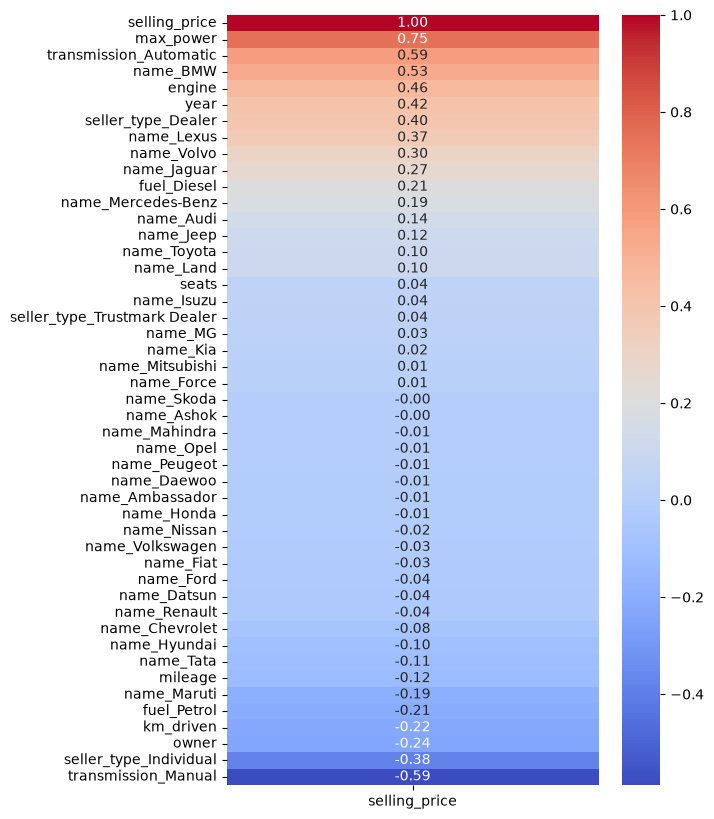

In [25]:
target_corr = one_hot_encoding_df.corr()[["selling_price"]].sort_values(by="selling_price", ascending=False)

plt.figure(figsize=(6, 10))
sns.heatmap(target_corr, annot=True, cmap="coolwarm", fmt=".2f")

### choose the most salient X

- as we can see in correlation matrix, i pick the most features that |correlation index| > 20
- i didnt pick negative correlation index features such as (transmission_Manual, seller_type_Individual, owner, km_driven, fuel_Petrol) because all of them have very high correlation to the features we pick before.

In [26]:
# selected_features = ["max_power", "transmission_Automatic", "name_BMW", "year", "seller_type_Dealer", "name_Lexus", "name_Volvo", "name_Jaguar", "fuel_Diesel"]
# X = one_hot_encoding_df[selected_features]

selected_features = ["max_power", "year"]
X = df[selected_features]

### Specify the y

In [66]:
y = df['selling_price']
# y = np.log(df['selling_price'])
y

0       450000
1       370000
2       158000
3       225000
4       130000
         ...  
8123    320000
8124    135000
8125    382000
8126    290000
8127    290000
Name: selling_price, Length: 8028, dtype: int64

<Axes: ylabel='selling_price'>

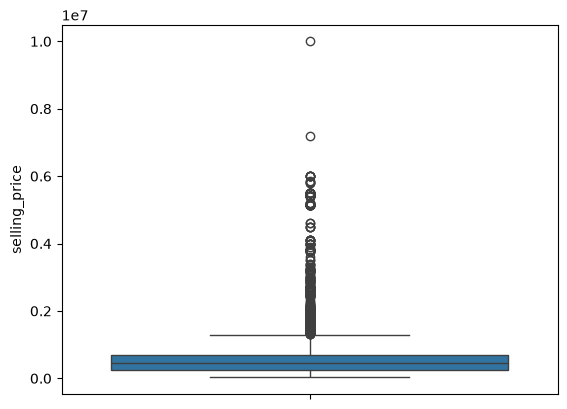

In [28]:
sns.boxplot(data=y)

In [67]:
test = pd.qcut(y, q=4)
test.value_counts()

selling_price
(29998.999, 260000.0]     2050
(260000.0, 450000.0]      2044
(680000.0, 10000000.0]    1991
(450000.0, 680000.0]      1943
Name: count, dtype: int64

#### binning 'selling_price' to 0, 1, 2, 3

In [70]:
y_binned, bin_edges = pd.qcut(y, q=4, labels=False, retbins=True)
print(bin_edges)    # 5 values: the 4 bin boundaries, from min to max
y_binned


[   29999.   260000.   450000.   680000. 10000000.]


0       1
1       1
2       0
3       0
4       0
       ..
8123    1
8124    0
8125    1
8126    1
8127    1
Name: selling_price, Length: 8028, dtype: int64

In [73]:
Y = pd.get_dummies(y_binned, prefix='price_tier', dtype=int)
print(Y.head())
print(bin_edges)
print(y.head())

   price_tier_0  price_tier_1  price_tier_2  price_tier_3
0             0             1             0             0
1             0             1             0             0
2             1             0             0             0
3             1             0             0             0
4             1             0             0             0
[   29999.   260000.   450000.   680000. 10000000.]
0    450000
1    370000
2    158000
3    225000
4    130000
Name: selling_price, dtype: int64


In [74]:
class_names = [f"{bin_edges[i]:,.0f} - {bin_edges[i+1]:,.0f}" for i in range(4)]
class_names

['29,999 - 260,000',
 '260,000 - 450,000',
 '450,000 - 680,000',
 '680,000 - 10,000,000']

### Splitting

In [32]:
from sklearn.model_selection import train_test_split

random_state = 42
test_size = 0.2

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = test_size, random_state = random_state)

In [33]:
print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(6422, 2) (1606, 2)
(6422, 4) (1606, 4)


## 4. Preprocessing

preprocessing TRAINING DATA

### checking null values

In [34]:
print(Y.isna().sum())

price_tier_0    0
price_tier_1    0
price_tier_2    0
price_tier_3    0
dtype: int64


In [35]:
for col in X_train.columns:
    print(col, X_train[col].isna().sum())

max_power 165
year 0


### checking distribution of each features

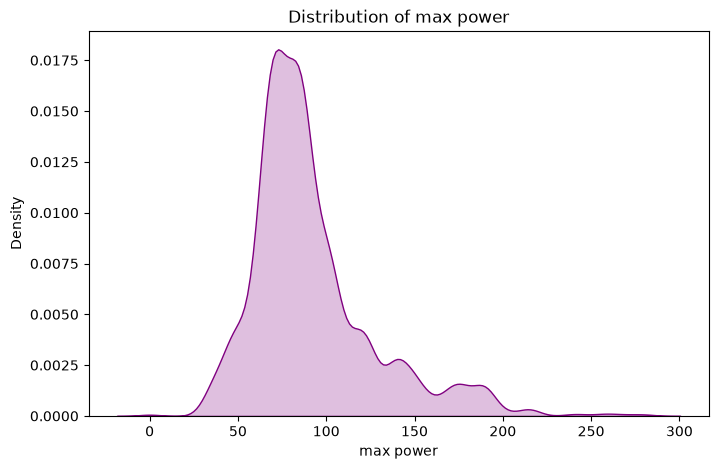

In [36]:
plt.figure(figsize=(8, 5))
sns.kdeplot(X_train["max_power"], fill=True, color='purple')
plt.title("Distribution of max power")
plt.xlabel("max power")
plt.show()

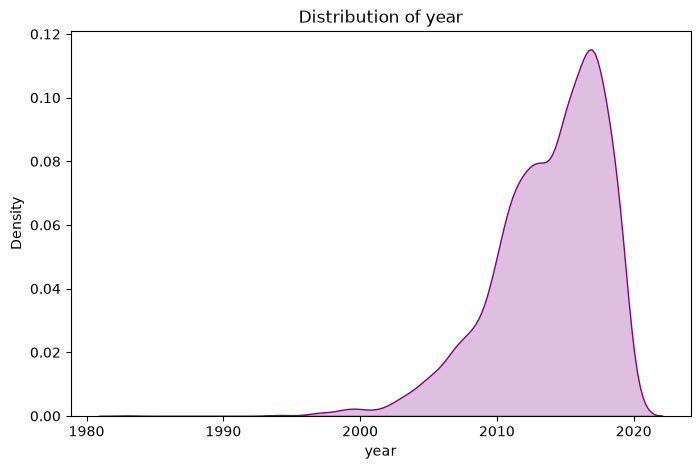

In [37]:
plt.figure(figsize=(8, 5))
sns.kdeplot(X_train["year"], fill=True, color='purple')
plt.title("Distribution of year")
plt.xlabel("year")
plt.show()

### checking outliers

In [38]:
def outlier_count(col, data = X_train):

    # calculate your 25% quatile and 75% quatile
    q75, q25 = np.percentile(data[col], [75, 25])

    # calculate your inter quatile
    iqr = q75 - q25

    # min_val and max_val
    min_val = q25 - (iqr*1.5)
    max_val = q75 + (iqr*1.5)

    # count number of outliers, which are the data that are less than min_val or more than max_val calculated above
    outlier_count = len(np.where((data[col] > max_val) | (data[col] < min_val))[0])

    # calculate the percentage of the outliers
    outlier_percent = round(outlier_count/len(data[col])*100, 2)

    # if(outlier_count > 0):
    print("\n"+15*'-' + col + 15*'-'+"\n")
    print('Number of outliers: {}'.format(outlier_count))
    print('Percent of data that is outlier: {}%'.format(outlier_percent))

In [39]:
for col in X_train.columns:
    outlier_count(col)


---------------max_power---------------

Number of outliers: 0
Percent of data that is outlier: 0.0%

---------------year---------------

Number of outliers: 63
Percent of data that is outlier: 0.98%


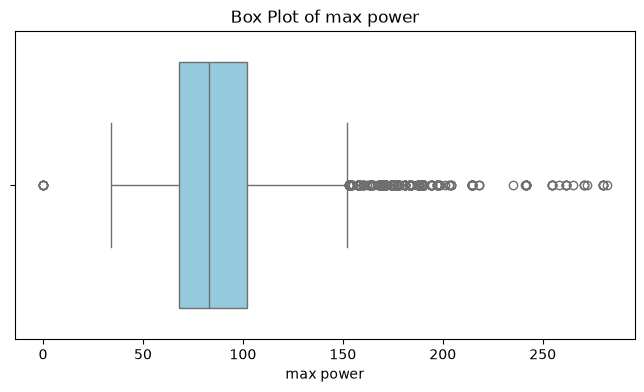

In [40]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=X_train['max_power'], color='skyblue')
plt.title("Box Plot of max power")
plt.xlabel("max power")
plt.show()

### Replacing NaN (null with median)

replacing null with median because we can see that the trend of max_power data is squeeze.

In [41]:
median_max_power = X_train["max_power"].median()

X_train["max_power"] = X_train["max_power"].fillna(median_max_power)
X_test["max_power"] = X_test["max_power"].fillna(median_max_power)

In [42]:
print(X_train["max_power"].median())
print(X_train["year"].median())

82.85
2015.0


### Scale features

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit on train only
X_test  = scaler.transform(X_test)

Y_train = Y_train.to_numpy() 
Y_test  = Y_test.to_numpy()  

## 5. Modeling

### define Logistic Regression class from scratch

In [45]:
class LogisticRegression:
    
    def __init__(self, k, n, method, alpha = 0.001, max_iter=5000, regularization=None):
        '''
        k: number of classes
        n: number of features
        '''
        self.k = k           
        self.n = n
        self.alpha = alpha
        self.max_iter = max_iter
        self.method = method
        self.regularization = regularization
    
    def fit(self, X, Y):
        self.W = np.random.rand(self.n, self.k) # (n, k)
        self.b = np.zeros(self.k)               # (k,)
        self.losses = []
        
        if self.method == "batch":
            start_time = time.time()
            for i in range(self.max_iter):
                loss, grad_W, grad_b = self.gradient(X, Y)
                self._update(loss, grad_W, grad_b, i)
            print(f"time taken: {time.time() - start_time}")
            
        elif self.method == "minibatch":
            start_time = time.time()
            batch_size = int(0.3 * X.shape[0])
            for i in range(self.max_iter):
                ix = np.random.randint(0, X.shape[0]) #<----with replacement
                batch_X = X[ix:ix+batch_size]
                batch_Y = Y[ix:ix+batch_size]
                loss, grad_W, grad_b = self.gradient(batch_X, batch_Y)
                self._update(loss, grad_W, grad_b, i)
            print(f"time taken: {time.time() - start_time}")
            
        elif self.method == "sto":
            start_time = time.time()
            list_of_used_ix = set()
            for i in range(self.max_iter):
                idx = np.random.randint(X.shape[0])
                while idx in list_of_used_ix:
                    idx = np.random.randint(X.shape[0])
                X_train = X[idx, :].reshape(1, -1)
                Y_train = Y[idx]
                loss, grad_W, grad_b = self.gradient(X_train, Y_train)
                self._update(loss, grad_W, grad_b, i)
                
                list_of_used_ix.add(idx)
                if len(list_of_used_ix) == X.shape[0]:
                    list_of_used_ix = set()
            print(f"time taken: {time.time() - start_time}")
            
        else:
            raise ValueError('Method must be one of the followings: "batch", "minibatch" or "sto".')
        
    def gradient(self, X, Y):
        m = X.shape[0]
        h = self.h_theta(X, self.W, self.b)
        loss = - np.sum(Y*np.log(h + 1e-12)) / m
        error = h - Y
        grad_W = self.softmax_grad(X, error) / m
        grad_b = error.sum(axis=0) / m

        if self.regularization is not None:
            loss += self.regularization(self.W)
            grad_W += self.regularization.derivation(self.W)

        return loss, grad_W, grad_b
    
    def _update(self, loss, grad_W, grad_b, i):
        self.losses.append(loss)
        self.W = self.W - self.alpha * grad_W
        self.b = self.b - self.alpha * grad_b
        if i % 500 == 0:
            print(f"Loss at iteration {i}", loss)

    def softmax(self, theta_t_x):
        return np.exp(theta_t_x) / np.sum(np.exp(theta_t_x), axis=1, keepdims=True)

    def softmax_grad(self, X, error):
        return  X.T @ error

    def h_theta(self, X, W, b):
        '''
        Input:
            X shape: (m, n)
            w shape: (n, k)
            b shape: (k, )
        Returns:
            yhat shape: (m, k)
        '''
        return self.softmax(X @ W + b)
    
    def predict(self, X_test):
        return np.argmax(self.h_theta(X_test, self.W, self.b), axis=1)

    # ============================================================================
    def _pred_onehot(self, X):
        h = self.h_theta(X, self.W, self.b)
        return np.eye(h.shape[1])[np.argmax(h, axis=1)]

    def feature_importance(self, feature_names, per_class=False, class_names=None):
        '''
        Importance based on the learned weights self.W (n, k), centered across classes.
        - per_class=False: Series, mean absolute weight across classes (one ranking)
        - per_class=True : DataFrame of signed weights, one column per class,
                        rows sorted by the largest absolute weight
        feature_names must be in the same order as the columns of the X used for training.
        '''
        # remove the per-feature offset shared by all classes (it doesn't affect predictions)
        W = self.W - self.W.mean(axis=1, keepdims=True)

        if per_class:
            cols = class_names if class_names is not None else range(W.shape[1])
            df = pd.DataFrame(W, index=feature_names, columns=cols)
            order = df.abs().max(axis=1).sort_values(ascending=False).index
            return df.loc[order]

        return pd.Series(np.abs(W).mean(axis=1), index=feature_names).sort_values(ascending=False)
 

    @staticmethod
    def _safe_divide(numerator, denominator):
        numerator = np.asarray(numerator, dtype=float)
        denominator = np.asarray(denominator, dtype=float)
        result = np.divide(numerator, denominator,
                        out=np.zeros_like(numerator),
                        where=denominator != 0)    
        return result[()]
    # ============================================================================

    # ============================================================================
    # Task 1.1: Add metric calculation functions for one class
    
    def _confusion_counts(self, X, Y, c):
        h = self._pred_onehot(X)[:, c]
        y = Y[:, c]

        tp = np.sum((h == 1) & (y == 1))
        fp = np.sum((h == 1) & (y == 0))
        fn = np.sum((h == 0) & (y == 1))
        tn = np.sum((h == 0) & (y == 0))
        return tp, fp, fn, tn
            
    def accuracy_score(self, X, Y, c):
        tp, fp, fn, tn = self._confusion_counts(X, Y, c)
        return self._safe_divide(tp + tn, tp + fp + fn + tn)

    def precision_score(self, X, Y, c):
        tp, fp, _, _ = self._confusion_counts(X, Y, c)
        return self._safe_divide(tp, tp + fp)

    def recall_score(self, X, Y, c):
        tp, _, fn, _ = self._confusion_counts(X, Y, c)
        return self._safe_divide(tp, tp + fn)

    def f1_score(self, X, Y, c):
        tp, fp, fn, _ = self._confusion_counts(X, Y, c)
        return self._safe_divide(2*tp, 2*tp + fp + fn) # (it is equal to (2 * precision * recall) / (precision + recall), we can get this formula from math)
    # ============================================================================

    # Task 1.2: Add macro calculation functions for all classes
    # ============================================================================
    def _all_class_confusion_counts(self, X, Y):
        H = self._pred_onehot(X)
        
        tp = np.sum((H == 1) & (Y == 1), axis=0)
        fp = np.sum((H == 1) & (Y == 0), axis=0)
        fn = np.sum((H == 0) & (Y == 1), axis=0)
        tn = np.sum((H == 0) & (Y == 0), axis=0)
        return tp, fp, fn, tn

    def macro_accuracy_score(self, X, Y):
        tp, fp, fn, tn = self._all_class_confusion_counts(X, Y)
        return np.mean(self._safe_divide(tp + tn, tp + fp + fn + tn))

    def macro_precision_score(self, X, Y):
        tp, fp, _, _ = self._all_class_confusion_counts(X, Y)
        return np.mean(self._safe_divide(tp, tp + fp))

    def macro_recall_score(self, X, Y):
        tp, _, fn, _ = self._all_class_confusion_counts(X, Y)
        return np.mean(self._safe_divide(tp, tp + fn))
    
    def macro_f1_score(self, X, Y):
        tp, fp, fn, _ = self._all_class_confusion_counts(X, Y)
        return np.mean(self._safe_divide(2*tp, 2*tp + fp + fn))
    # ============================================================================

    # ============================================================================
    # Task 1.3: Add weighted macro calculation functions for all classes
    def _class_weights(self, Y):
        return Y.sum(axis=0) / Y.sum()

    def weighted_accuracy_score(self, X, Y):
        tp, fp, fn, tn = self._all_class_confusion_counts(X, Y)
        return np.sum(self._class_weights(Y) * self._safe_divide(tp + tn, tp + fp + fn + tn))

    def weighted_precision_score(self, X, Y):
        tp, fp, _, _ = self._all_class_confusion_counts(X, Y)
        return np.sum(self._class_weights(Y) * self._safe_divide(tp, tp + fp))
        
    def weighted_recall_score(self, X, Y):
        tp, _, fn, _ = self._all_class_confusion_counts(X, Y)
        return np.sum(self._class_weights(Y) * self._safe_divide(tp, tp + fn))
    
    def weighted_f1_score(self, X, Y):
        tp, fp, fn, _ = self._all_class_confusion_counts(X, Y)
        return np.sum(self._class_weights(Y) * self._safe_divide(2*tp, 2*tp + fp + fn))
    # ============================================================================

    def plot(self):
        plt.plot(np.arange(len(self.losses)) , self.losses, label = "Train Losses")
        plt.title("Losses")
        plt.xlabel("epoch")
        plt.ylabel("losses")
        plt.legend()

In [46]:
from sklearn.metrics import classification_report

# --- mock data ---
rng = np.random.default_rng(0)
n, k = 500, 4
labels = rng.choice(k, size=n, p=[0.1, 0.1, 0.4, 0.4])
Y = np.eye(k)[labels]
noisy = np.where(rng.random(n) < 0.7, labels, rng.integers(0, k, n))
H = np.eye(k)[noisy]
X = np.zeros((n, 1)) 

# --- stand-in ---
class MockModel(LogisticRegression):
    def __init__(self):    
        self.W = None
        self.b = None
    def h_theta(self, X, W, b):
        return H

mock_model = MockModel()

# --- sklearn ---
print(" ---------------------------- SKLEARN ---------------------------")
print(classification_report(Y, H, digits=4, zero_division=0))

# --- mine ---
print(" ------------------------------ MINE ----------------------------")
support = Y.sum(axis=0).astype(int)
n = support.sum()
print(f"{'':>12}  {'precision':>9} {'recall':>9} {'f1-score':>9} {'support':>9}\n")

for c in range(k):
    print(f"{c:>12}  {mock_model.precision_score(X, Y, c):>9.4f} "
          f"{mock_model.recall_score(X, Y, c):>9.4f} "
          f"{mock_model.f1_score(X, Y, c):>9.4f} {support[c]:>9d}")

print()
print(f"{'macro avg':>12}  {mock_model.macro_precision_score(X, Y):>9.4f} "
      f"{mock_model.macro_recall_score(X, Y):>9.4f} "
      f"{mock_model.macro_f1_score(X, Y):>9.4f} {n:>9d}")
print(f"{'weighted avg':>12}  {mock_model.weighted_precision_score(X, Y):>9.4f} "
      f"{mock_model.weighted_recall_score(X, Y):>9.4f} "
      f"{mock_model.weighted_f1_score(X, Y):>9.4f} {n:>9d}")

 ---------------------------- SKLEARN ---------------------------
              precision    recall  f1-score   support

           0     0.4839    0.6383    0.5505        47
           1     0.5246    0.6531    0.5818        49
           2     0.8424    0.7433    0.7898       187
           3     0.8585    0.8387    0.8485       217

   micro avg     0.7660    0.7660    0.7660       500
   macro avg     0.6773    0.7183    0.6926       500
weighted avg     0.7845    0.7660    0.7724       500
 samples avg     0.7660    0.7660    0.7660       500

 ------------------------------ MINE ----------------------------
              precision    recall  f1-score   support

           0     0.4839    0.6383    0.5505        47
           1     0.5246    0.6531    0.5818        49
           2     0.8424    0.7433    0.7898       187
           3     0.8585    0.8387    0.8485       217

   macro avg     0.6773    0.7183    0.6926       500
weighted avg     0.7845    0.7660    0.7724       500

```
Q: Just a brief question here: what does support in the classification report means? 
A: The number of samples of each class, for the above example
    class 0 has 47  samples
    class 1 has 49  samples
    class 2 has 187 samples
    class 3 has 217 samples
```

### Penalty classes

In [47]:
class RidgePenalty:

    def __init__(self, l):
        self.l = l

    def __call__(self, theta): #__call__ allows us to call class as method
        return self.l * np.sum(np.square(theta))

    def derivation(self, theta):
        return self.l * 2 * theta

### Grid search

In [48]:
mlflow.set_experiment("st126894-experiment")

# Param gird
param_grid = {
    "method":   ["sto", "minibatch", "batch"],
    "alpha":    [0.01, 0.001, 0.0001],
    "l":        [0, 0.001, 0.01, 1.0]
}

# Generate all unique combinations
keys, values = zip(*param_grid.items())
experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

2026/10/02 12:32:48 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/10/02 12:32:48 INFO mlflow.store.db.utils: Updating database tables
2026/10/02 12:32:51 INFO mlflow.tracking.fluent: Experiment with name 'st126894-experiment' does not exist. Creating a new experiment.


In [49]:
# Run the grid
for i, config in enumerate(experiments):
    method = config["method"]
    alpha = config["alpha"]
    l = config["l"]

    run_name = f"{method}_lr_{alpha}_ridge_{l}" if l > 0 else f"{method}_lr_{alpha}_no_ridge"

    print(f"{i}:\t{run_name}")
    with mlflow.start_run(run_name=run_name):
        reg = RidgePenalty(l) if l > 0 else None

        mlflow.log_params({
            "method": method,
            "alpha": alpha,
            "use_ridge": l > 0,
            "lambda": l,
        })

        # Train model
        model = LogisticRegression(
            k=Y_train.shape[1], # Number of labels
            n=X_train.shape[1], # Number of features
            method=method,
            alpha=alpha,
            regularization=reg
        )
        model.fit(X_train, Y_train)

        # Log evaluation metrics
        mlflow.log_metrics({
            "train_loss": float(model.losses[-1]),
            "train_accuracy": float(model.macro_accuracy_score(X_train, Y_train)),
            "train_macro_f1": float(model.macro_f1_score(X_train, Y_train)),
            
            "test_macro_accuracy": float(model.macro_accuracy_score(X_test, Y_test)),
            "test_macro_precision": float(model.macro_precision_score(X_test, Y_test)),
            "test_macro_recall": float(model.macro_recall_score(X_test, Y_test)),
            "test_macro_f1": float(model.macro_f1_score(X_test, Y_test)),

            "test_weighted_accuracy": float(model.weighted_accuracy_score(X_test, Y_test)),
            "test_weighted_precision": float(model.weighted_precision_score(X_test, Y_test)),
            "test_weighted_recall": float(model.weighted_recall_score(X_test, Y_test)),
            "test_weighted_f1": float(model.weighted_f1_score(X_test, Y_test)),
        })

        # Log the trained model artifact
        mlflow.sklearn.log_model(
            model,
            name="model",
            skops_trusted_types=["__main__.LogisticRegression", "__main__.RidgePenalty"],
        )

0:	sto_lr_0.01_no_ridge
Loss at iteration 0 1.1520674308738248
Loss at iteration 500 0.432415357845367
Loss at iteration 1000 1.446824474134116
Loss at iteration 1500 1.0514177107469627
Loss at iteration 2000 0.2152120229593224
Loss at iteration 2500 1.3405343780840004
Loss at iteration 3000 1.3195497142619517
Loss at iteration 3500 2.4817481456741968
Loss at iteration 4000 0.0003076046545345565
Loss at iteration 4500 0.10019458068419142


2026/10/02 12:32:51 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Dev\University\AIT\ML\Coding_Assignments\A3


time taken: 0.2413623332977295


2026/10/02 12:32:55 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Dev\University\AIT\ML\Coding_Assignments\A3
2026/10/02 12:32:55 INFO mlflow.utils.environment: Detected uv project at c:\Dev\University\AIT\ML\Coding_Assignments\A3. Attempting to export requirements via 'uv export'.
2026/10/02 12:32:56 INFO mlflow.utils.uv_utils: Exported 91 dependencies via uv
2026/10/02 12:32:56 INFO mlflow.utils.environment: Successfully exported 91 requirements from uv project. Skipping package capture based inference.
2026/10/02 12:33:01 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


1:	sto_lr_0.01_ridge_0.001
Loss at iteration 0 1.2237998352557957
Loss at iteration 500 1.3532982359564976
Loss at iteration 1000 0.9717004997518328
Loss at iteration 1500 0.632240935939056
Loss at iteration 2000 0.40890022047197033
Loss at iteration 2500 1.1806833455949273
Loss at iteration 3000 0.40428817957205143
Loss at iteration 3500 1.041361365356134


...

2026/10/02 12:35:23 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Dev\University\AIT\ML\Coding_Assignments\A3
2026/10/02 12:35:23 INFO mlflow.utils.environment: Detected uv project at c:\Dev\University\AIT\ML\Coding_Assignments\A3. Attempting to export requirements via 'uv export'.
2026/10/02 12:35:23 INFO mlflow.utils.uv_utils: Exported 91 dependencies via uv
2026/10/02 12:35:23 INFO mlflow.utils.environment: Successfully exported 91 requirements from uv project. Skipping package capture based inference.
2026/10/02 12:35:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


35:	batch_lr_0.0001_ridge_1.0
Loss at iteration 0 6.111052488490877
Loss at iteration 500 5.2318579152449205
Loss at iteration 1000 4.514598263000776
Loss at iteration 1500 3.9294989413747685
Loss at iteration 2000 3.4522400368754127
Loss at iteration 2500 3.062963213562023
Loss at iteration 3000 2.745457843902045
Loss at iteration 3500 2.4864943042011936
Loss at iteration 4000 2.275278105890176
Loss at iteration 4500 2.103003219777496


2026/10/02 12:35:28 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Dev\University\AIT\ML\Coding_Assignments\A3


time taken: 4.44413948059082


2026/10/02 12:35:29 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Dev\University\AIT\ML\Coding_Assignments\A3
2026/10/02 12:35:29 INFO mlflow.utils.environment: Detected uv project at c:\Dev\University\AIT\ML\Coding_Assignments\A3. Attempting to export requirements via 'uv export'.
2026/10/02 12:35:30 INFO mlflow.utils.uv_utils: Exported 91 dependencies via uv
2026/10/02 12:35:30 INFO mlflow.utils.environment: Successfully exported 91 requirements from uv project. Skipping package capture based inference.
2026/10/02 12:35:30 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


## 6. Testing

## test the model with the best parameter (sort by weight f1 score)



![Screenshot 2026-10-02 211515.png](images/mlflow_runs.png)
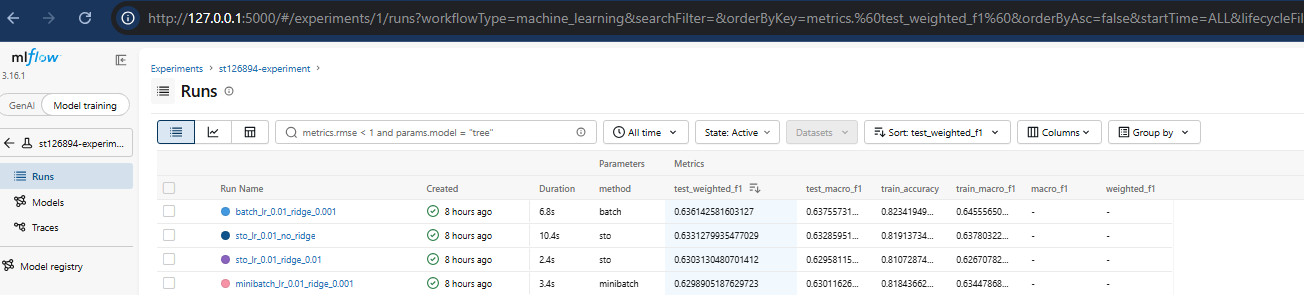
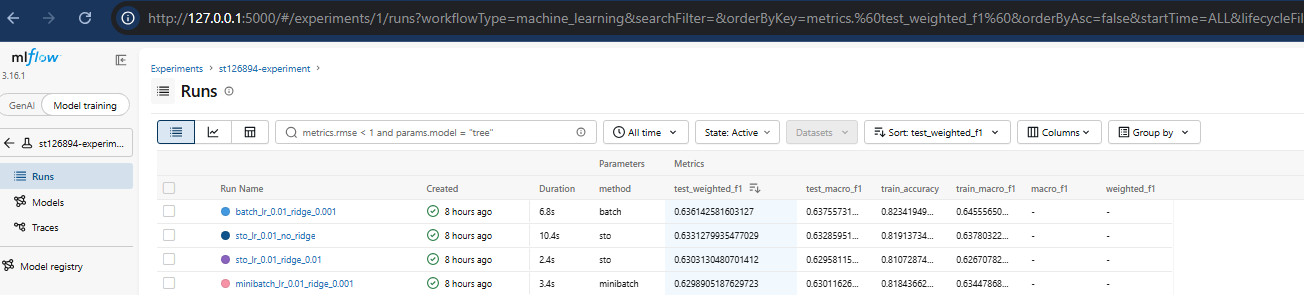

In [89]:
best_model = LogisticRegression(
            k=Y_train.shape[1], # Number of labels
            n=X_train.shape[1], # Number of features
            method='batch',
            alpha=0.01,
            regularization=RidgePenalty(0.001)
)

In [90]:
best_model.fit(X_train, Y_train)

Loss at iteration 0 1.274970937806935
Loss at iteration 500 0.9970833080208189
Loss at iteration 1000 0.9337985218732607
Loss at iteration 1500 0.9013320463585786
Loss at iteration 2000 0.8807924904381663
Loss at iteration 2500 0.8665579225978598
Loss at iteration 3000 0.8561623904040675
Loss at iteration 3500 0.8483029927946723
Loss at iteration 4000 0.842211241070627
Loss at iteration 4500 0.8373995632845055
time taken: 4.090899705886841


In [91]:
print(f"{'':>12}  {'precision':>9} {'recall':>9} {'f1-score':>9} {'support':>9}\n")

for c in range(Y_test.shape[1]):
    print(f"{c:>12}  {best_model.precision_score(X_test, Y_test, c):>9.4f} "
          f"{best_model.recall_score(X_test, Y_test, c):>9.4f} "
          f"{best_model.f1_score(X_test, Y_test, c):>9.4f} {support[c]:>9d}")

print()
print(f"{'macro avg':>12}  {best_model.macro_precision_score(X_test, Y_test):>9.4f} "
      f"{best_model.macro_recall_score(X_test, Y_test):>9.4f} "
      f"{best_model.macro_f1_score(X_test, Y_test):>9.4f} {n:>9d}")
print(f"{'weighted avg':>12}  {best_model.weighted_precision_score(X_test, Y_test):>9.4f} "
      f"{best_model.weighted_recall_score(X_test, Y_test):>9.4f} "
      f"{best_model.weighted_f1_score(X_test, Y_test):>9.4f} {n:>9d}")

              precision    recall  f1-score   support

           0     0.7400    0.8102    0.7735        47
           1     0.5603    0.4583    0.5042        49
           2     0.4709    0.5739    0.5173       187
           3     0.7712    0.7054    0.7368       217

   macro avg     0.6356    0.6370    0.6330       500
weighted avg     0.6375    0.6333    0.6321       500


## 7. Analysis (Feature Importance)

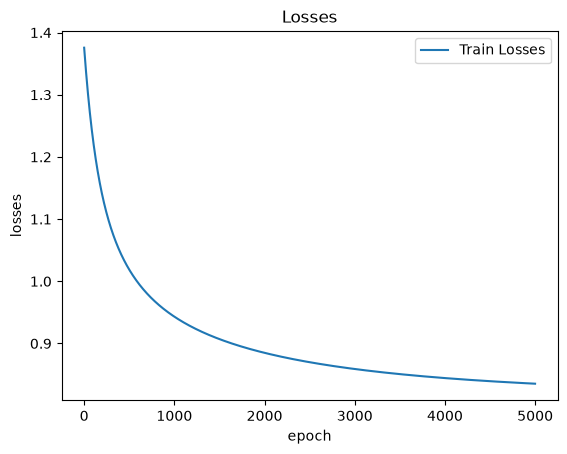

In [53]:
best_model.plot()

In [ ]:
print(best_model.feature_importance(feature_names=selected_features, per_class=False))
print(best_model.feature_importance(feature_names=selected_features, per_class=True))


year         1.231869
max_power    1.042390
dtype: float64
                  0         1         2         3
year      -1.991907 -0.471831  0.774917  1.688820
max_power -1.573106 -0.511675  0.432845  1.651936


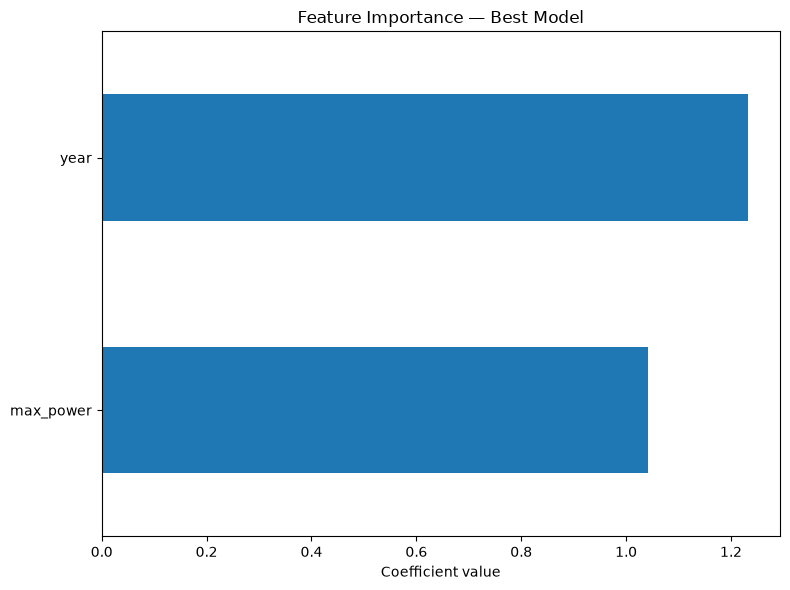

In [55]:
feat_importance = best_model.feature_importance(feature_names=selected_features, per_class=False)

feat_importance.plot(kind="barh", figsize=(8, 6))
plt.title("Feature Importance — Best Model")
plt.xlabel("Coefficient value")
plt.gca().invert_yaxis()   # <-- without this, highest value ends up at the BOTTOM
plt.tight_layout()
plt.show()

### Save Model

In [75]:
filename = "model/a3_model.pkl"
save_params = {
    "model": best_model,
    "scaler": scaler,                         
    "feature_names": list(selected_features), 
    "bin_edges": bin_edges,
    "class_names": class_names,
}
joblib.dump(save_params, filename)

['model/a3_model.pkl']

## 8. Inference

In [ ]:
bundle = joblib.load("model/a3_model.pkl")
loaded_model, loaded_scaler = bundle["model"], bundle["scaler"]
class_names = bundle["class_names"]

In [77]:
df[["max_power", "year", "selling_price"]].iloc[:5]

,max_power,year,selling_price
0,74.00,2014,450000
1,103.52,2014,370000
2,78.00,2006,158000
3,90.00,2010,225000
4,88.20,2007,130000


In [78]:
samples = df[["max_power", "year"]].iloc[:5].copy()
samples_scaled = loaded_scaler.transform(samples)           # same StandardScaler fit on X_train
samples_scaled

array([[-0.4994218 ,  0.04494691],
       [ 0.34024827,  0.04494691],
       [-0.38564537, -1.93210129],
       [-0.04431607, -0.94357719],
       [-0.09551547, -1.68497026]])

In [79]:
predicted_cost = loaded_model.predict(samples_scaled)
predicted_cost

array([1, 2, 0, 0, 0])

In [81]:
print([class_names[p] for p in predicted_cost]) 
df[["selling_price"]].iloc[:5]

['260,000 - 450,000', '450,000 - 680,000', '29,999 - 260,000', '29,999 - 260,000', '29,999 - 260,000']


,selling_price
0,450000
1,370000
2,158000
3,225000
4,130000


#  9. Deployment

## Deploy the best model  to Mlflow registry

In [83]:
import mlflow, mlflow.pyfunc

class LogRegWrapper(mlflow.pyfunc.PythonModel):
    def __init__(self, model, scaler, feature_names, num_cols, class_names):
        self.model = model
        self.scaler = scaler
        self.feature_names = feature_names
        self.num_cols = num_cols
        self.class_names = class_names

    def predict(self, context, model_input, params=None):
        X = pd.DataFrame(model_input)[self.feature_names].astype(float)   # fixes column order
        X[self.num_cols] = self.scaler.transform(X[self.num_cols])        # numeric columns only
        pred = self.model.predict(X.to_numpy())
        return pd.DataFrame({
            "price_tier": pred,
            "price_range": [self.class_names[p] for p in pred],
        })

c:\Dev\University\AIT\ML\Coding_Assignments\A3\.venv\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [84]:
MODEL_NAME = "st126894-a3-model"  
num_cols = ["max_power", "year"]

input_example = df[selected_features].iloc[:3]   # raw, unscaled rows

with mlflow.start_run(run_name="best-model"):
    mlflow.log_params({
        "method": best_model.method,
        "alpha": best_model.alpha,
        "regularization": type(best_model.regularization).__name__,
    })
    mlflow.log_metric("macro_f1", best_model.macro_f1_score(X_test, Y_test))
    mlflow.log_metric("weighted_f1", best_model.weighted_f1_score(X_test, Y_test))

    mlflow.pyfunc.log_model(
        artifact_path="model",
        python_model=LogRegWrapper(best_model, scaler, list(selected_features), num_cols, class_names),
        input_example=input_example,
        registered_model_name=MODEL_NAME,
    )

2026/10/02 14:03:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/02 14:03:30 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Dev\University\AIT\ML\Coding_Assignments\A3
2026/10/02 14:03:30 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/10/02 14:03:30 INFO mlflow.pyfunc: Inferring model signature from input example
c:\Dev\University\AIT\ML\Coding_Assignments\A3\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference t

In [85]:
loaded = mlflow.pyfunc.load_model(f"models:/{MODEL_NAME}/1")
print(loaded.predict(df[selected_features].iloc[:5]))

   price_tier        price_range
0           1  260,000 - 450,000
1           2  450,000 - 680,000
2           0   29,999 - 260,000
3           0   29,999 - 260,000
4           0   29,999 - 260,000


## screenshot show that the best model has been deployed on MLFlow Registry with 'Staging' status

![Screenshot 2026-10-02 211420.png](images/mlflow_registry.png)
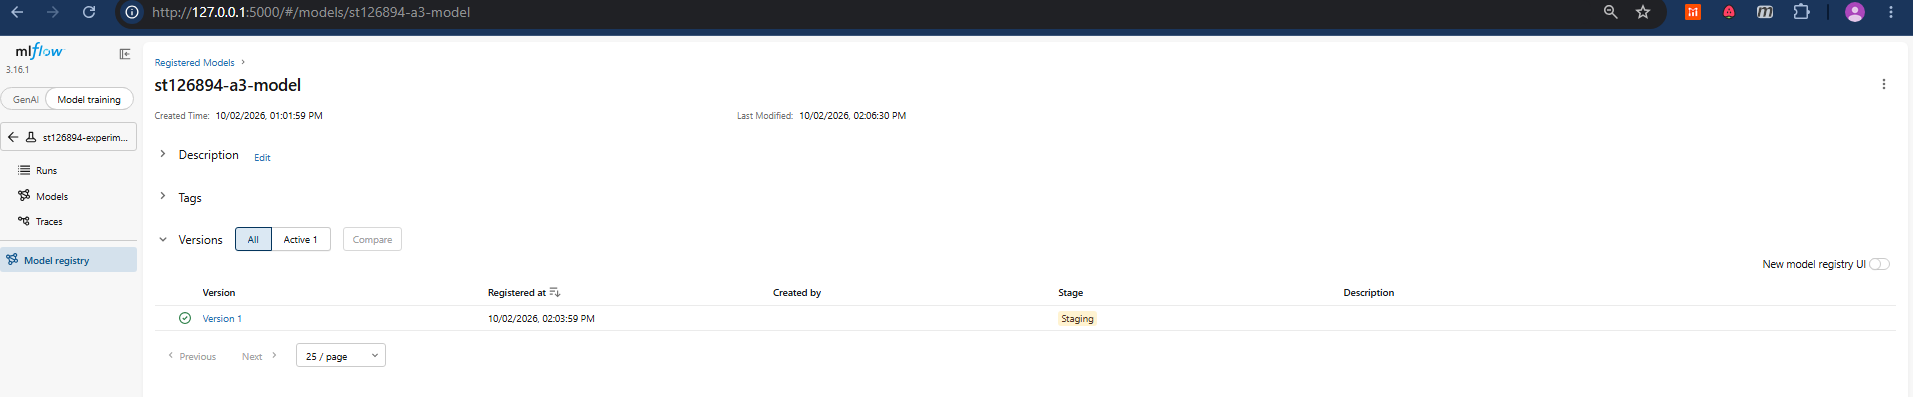
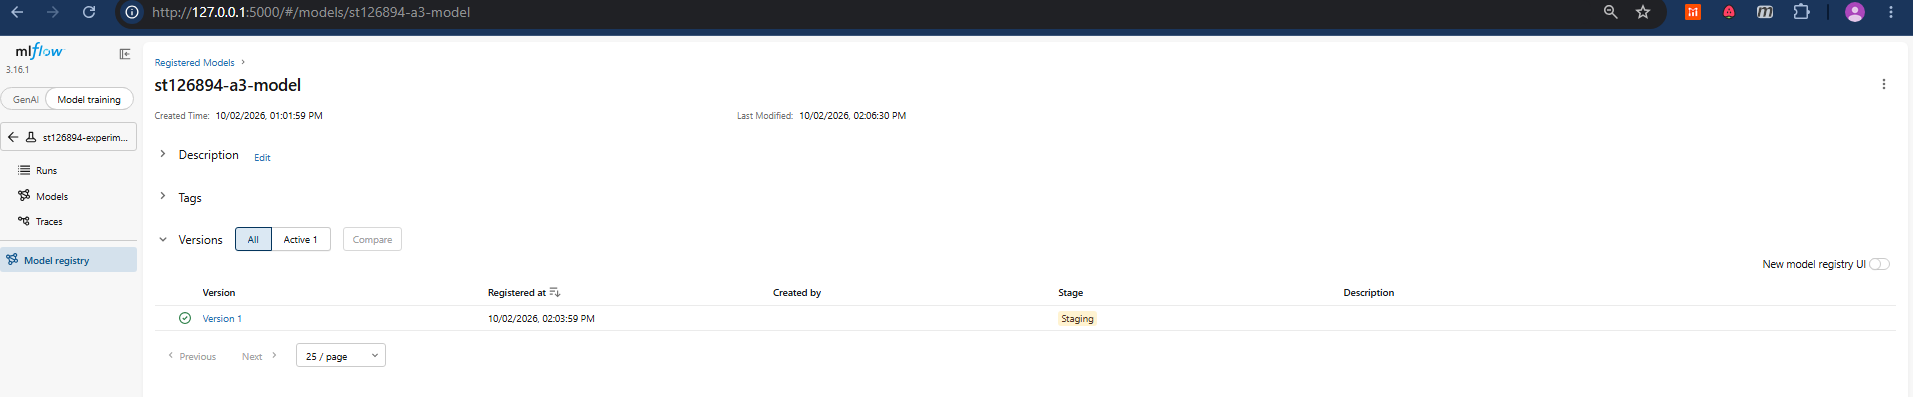

# Report


### 1. Overview
In this assignment, we implemented Multiclass Logistic Regression from scratch with Softmax and Ridge (L2) regularization.
We ran a grid search with **36 hyperparameter combinations** tracked in **MLflow**:
- **3 Methods:** Batch, Mini-batch, and Stochastic (`sto`).
- **3 Learning rates:** 0.01, 0.001, and 0.0001.
- **4 Regularization values (lambda):** 0 (no ridge), 0.001, 0.01, and 1.0.

---
### 2. MLflow Tracking
#### Experiment Leaderboard & Best Run
![MLflow Experiment Runs](images/Screenshot%202026-10-02%20211515.png)

#### Model Registry ('Staging' Status)
![MLflow Registry](images/Screenshot%202026-10-02%20211420.png)

---
### 3. Comparison Table (Best for each method)
| Method | Learning Rate | Ridge Lambda | Train Loss | Test Weighted F1 | Test Macro F1 | Test Accuracy |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Batch** *(Best)* | 0.01 | 0.001 | 0.8349 | **0.6361** | **0.6376** | **81.72%** |
| **Stochastic (`sto`)** | 0.01 | 0 (none) | 0.0976 | 0.6331 | 0.6329 | 81.51% |
| **Mini-batch** | 0.01 | 0.001 | 0.8452 | 0.6299 | 0.6301 | 81.48% |

---
### 4. Key Findings and Discussion

1. **Which method worked best?**
   - **Batch gradient descent** gave the best result on the test set (Weighted F1 = 0.6361). Because our dataset is not too large and the loss curve is smooth, batch gradient descent takes steady and clean steps.
   - **Stochastic (`sto`)** was also strong (F1 = 0.6331) and had very low train loss, but it jumps around near the minimum because it updates on one sample at a time.
   - **Mini-batch** was in between (F1 = 0.6299).

2. **Learning Rate:**
   - **0.01** was the best learning rate for all methods.
   - Smaller learning rates (0.001 and 0.0001) learned too slowly. Within 3000 iterations, they did not reach good results.

3. **Ridge Regularization:**
   - A small lambda (**0.001**) helped prevent overfitting and gave the top model.
   - Too much regularization (lambda = 1.0) pushed the weights too close to zero and lowered accuracy.

4. **Class performance:**
   - **Tier 0 (Budget)** and **Tier 3 (Luxury)** were the easiest to classify (F1 = 0.77 and 0.74). Old low-power cars and new high-power cars are easy to separate.
   - **Tier 1 and Tier 2 (Mid-range)** were harder (F1 = 0.50 and 0.51) because their horsepower and year values overlap more.

---
### 5. Final Evaluation and Feature Importance

Best model: **Batch, lr = 0.01, Ridge = 0.001**
- **Test Weighted F1:** 0.6361
- **Test Accuracy:** 81.72%

#### Feature Importance:
- **`year` (importance: 1.23):**
  - Class 0 (Budget): **-1.99** (Older cars go to Budget tier)
  - Class 3 (Luxury): **+1.69** (Newer cars go to Luxury tier)
- **`max_power` (importance: 1.04):**
  - Class 0 (Budget): **-1.57** (Lower horsepower goes to Budget tier)
  - Class 3 (Luxury): **+1.65** (Higher horsepower goes to Luxury tier)

Both features show a clear trend: when a car is newer and has more horsepower, its probability moves smoothly from Tier 0 to Tier 3.

---
### 6. Deployment and CI/CD
- The model was packaged using MLflow `pyfunc` (with StandardScaler included) and registered in **'Staging'** status.
- Built a web interface and API using **FastAPI**, containerized with **Docker** and deployed on `ml-brain`.
- Added **GitHub Actions** CI/CD pipeline to run pytest unit tests automatically on every push.
